<a href="https://colab.research.google.com/github/elifia-muthia/6424-final-project/blob/main/project3/CPU_mem_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import glob
import numpy as np

In [ ]:
def analyze(log_path, title, bin_size_ms=100):
    # load json into df
    records = []
    with open(log_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    df = pd.DataFrame(records)

    # normalize timestamps to relative milliseconds (start from 0)
    df['rel_ms'] = df['timestamp_ms'] - df['timestamp_ms'].min()

    # summary statistics
    summary = {
        'duration_s': (df['rel_ms'].max() / 1000),
        'cpu_mean': df['cpu_percent'].mean(),
        'cpu_median': df['cpu_percent'].median(),
        'cpu_p95': df['cpu_percent'].quantile(0.95),
        'cpu_max': df['cpu_percent'].max(),
        'mem_mean_mb': df['mem_bytes'].mean() / (1024**2),
        'mem_median_mb': df['mem_bytes'].median() / (1024**2),
        'mem_p95_mb': df['mem_bytes'].quantile(0.95) / (1024**2),
        'mem_max_mb': df['mem_bytes'].max() / (1024**2),
    }
    summary_df = pd.DataFrame([summary])

    # cpu over time
    plt.figure(figsize=(8, 4))
    plt.plot(df['rel_ms'], df['cpu_percent'], linewidth=0.5)
    plt.title(f'CPU% Over Time for {title}')
    plt.xlabel('Relative Time (ms)')
    plt.ylabel('CPU %')
    plt.tight_layout()
    plt.show()

    # memory over time
    plt.figure(figsize=(8, 4))
    plt.plot(df['rel_ms'], df['mem_bytes'] / (1024**2), linewidth=0.5)
    plt.title(f'Memory (MB) Over Time for {title}')
    plt.xlabel('Relative Time (ms)')
    plt.ylabel('Memory (MB)')
    plt.tight_layout()
    plt.show()

    return summary_df

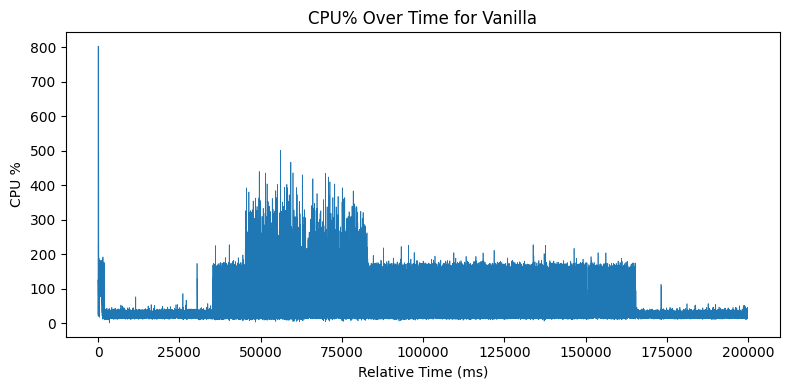

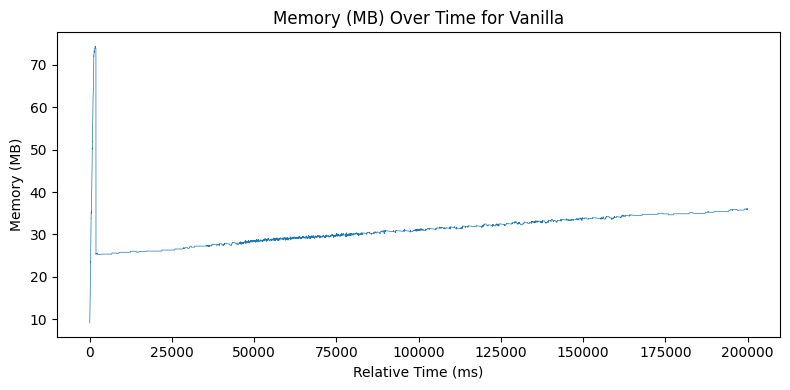

,duration_s,cpu_mean,cpu_median,cpu_p95,cpu_max,mem_mean_mb,mem_median_mb,mem_p95_mb,mem_max_mb
0,199.867,34.737456,24.4,102.208,803.59,31.153967,31.152344,35.363281,74.378906


In [ ]:
log_file = 'vanilla/cpu-memory-metrics-1.log'
stats = analyze(log_file, "Vanilla")
stats

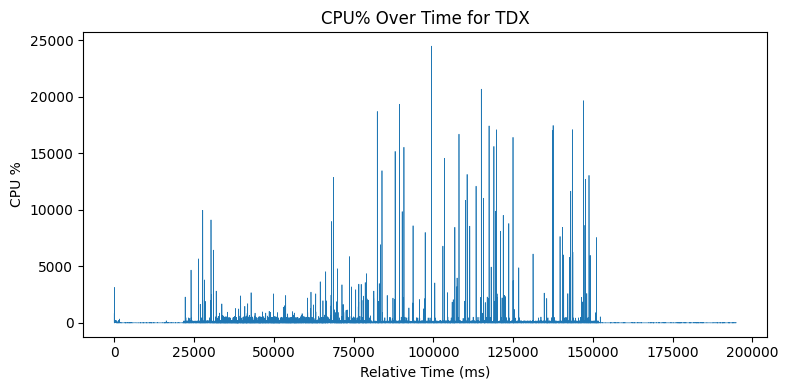

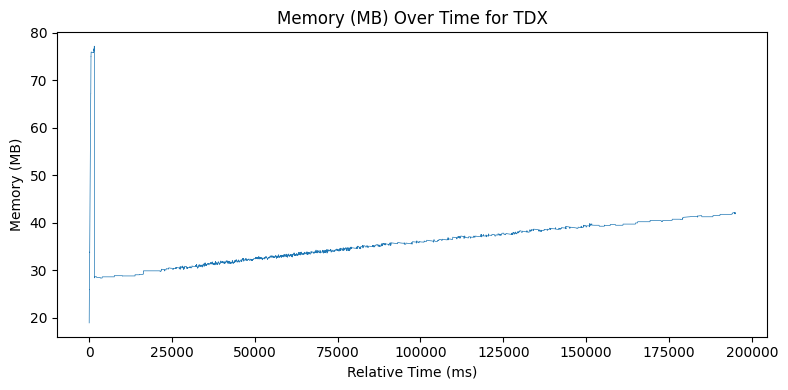

,duration_s,cpu_mean,cpu_median,cpu_p95,cpu_max,mem_mean_mb,mem_median_mb,mem_p95_mb,mem_max_mb
0,194.944,18.640693,6.95,61.1205,24492.96,35.92835,36.023438,41.332031,77.210938


In [ ]:
log_file = 'tdx/cpu-memory-metrics-1.log'
stats = analyze(log_file, "TDX")
stats